In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("seattleweather1948-2017_1738467795684.csv")

In [3]:
data.head()

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


In [4]:
data.describe

<bound method NDFrame.describe of              DATE  PRCP  TMAX  TMIN   RAIN
0      1948-01-01  0.47    51    42   True
1      1948-01-02  0.59    45    36   True
2      1948-01-03  0.42    45    35   True
3      1948-01-04  0.31    45    34   True
4      1948-01-05  0.17    45    32   True
...           ...   ...   ...   ...    ...
25546  2017-12-10  0.00    49    34  False
25547  2017-12-11  0.00    49    29  False
25548  2017-12-12  0.00    46    32  False
25549  2017-12-13  0.00    48    34  False
25550  2017-12-14  0.00    50    36  False

[25551 rows x 5 columns]>

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25551 entries, 0 to 25550
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    25551 non-null  object 
 1   PRCP    25548 non-null  float64
 2   TMAX    25551 non-null  int64  
 3   TMIN    25551 non-null  int64  
 4   RAIN    25548 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 998.2+ KB


In [7]:
data.isna().sum()

DATE    0
PRCP    3
TMAX    0
TMIN    0
RAIN    3
dtype: int64

In [8]:
data1 = data[data["PRCP"].isnull()]
data1

,DATE,PRCP,TMAX,TMIN,RAIN
18415,1998-06-02,NaN,72,52,NaN
18416,1998-06-03,NaN,66,51,NaN
21067,2005-09-05,NaN,70,52,NaN


In [10]:
data1 = data[data["RAIN"].isnull()]
data1

,DATE,PRCP,TMAX,TMIN,RAIN
18415,1998-06-02,NaN,72,52,NaN
18416,1998-06-03,NaN,66,51,NaN
21067,2005-09-05,NaN,70,52,NaN


In [12]:
data.shape

(25551, 5)

In [13]:
data = data.dropna()

In [14]:
data.head()

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


In [15]:
data1 = data[data["RAIN"].isnull()]
data1

,DATE,PRCP,TMAX,TMIN,RAIN


### Finding Outlier

<function matplotlib.pyplot.show(close=None, block=None)>

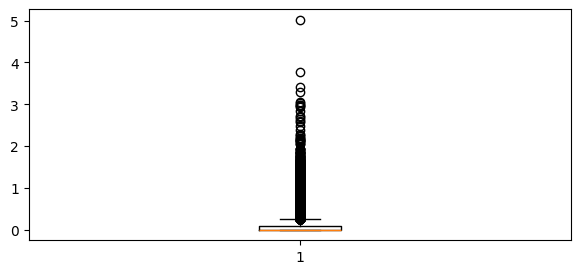

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,3))
plt.boxplot(data["PRCP"])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

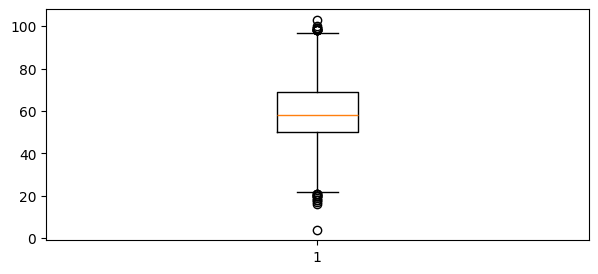

In [17]:
plt.figure(figsize=(7,3))
plt.boxplot(data["TMAX"])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

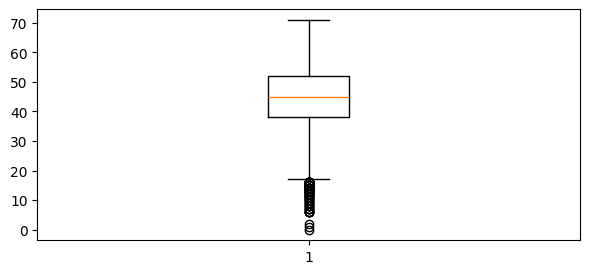

In [18]:
plt.figure(figsize=(7,3))
plt.boxplot(data["TMIN"])
plt.show

### Fill Outlier

In [19]:
Q1 = data["PRCP"].quantile(0.25)
Q3 = data["PRCP"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

lower_limit, upper_limit

(np.float64(-0.15000000000000002), np.float64(0.25))

In [20]:
data[data["PRCP"]>upper_limit].count()

DATE    3558
PRCP    3558
TMAX    3558
TMIN    3558
RAIN    3558
dtype: int64

In [22]:
data["PRCP"] = data["PRCP"].clip(lower=lower_limit, upper=upper_limit)

C:\Users\Dipak\AppData\Local\Temp\ipykernel_10584\825584541.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["PRCP"] = data["PRCP"].clip(lower=lower_limit, upper=upper_limit)


<function matplotlib.pyplot.show(close=None, block=None)>

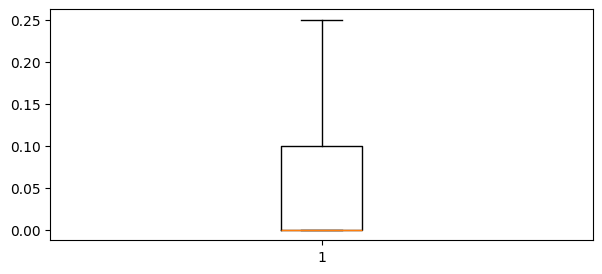

In [23]:
plt.figure(figsize=(7,3))
plt.boxplot(data["PRCP"])
plt.show

In [24]:
Q1 = data["TMAX"].quantile(0.25)
Q3 = data["TMAX"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

lower_limit, upper_limit

(np.float64(21.5), np.float64(97.5))

In [25]:
data["TMAX"] = data["TMAX"].clip(lower=lower_limit, upper=upper_limit)

C:\Users\Dipak\AppData\Local\Temp\ipykernel_10584\1224647762.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["TMAX"] = data["TMAX"].clip(lower=lower_limit, upper=upper_limit)


<function matplotlib.pyplot.show(close=None, block=None)>

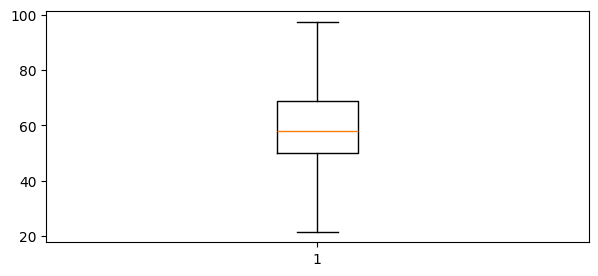

In [26]:
plt.figure(figsize=(7,3))
plt.boxplot(data["TMAX"])
plt.show

In [27]:
Q1 = data["TMIN"].quantile(0.25)
Q3 = data["TMIN"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

lower_limit, upper_limit

(np.float64(17.0), np.float64(73.0))

In [28]:
data["TMIN"] = data["TMIN"].clip(lower=lower_limit, upper=upper_limit)

C:\Users\Dipak\AppData\Local\Temp\ipykernel_10584\259779219.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["TMIN"] = data["TMIN"].clip(lower=lower_limit, upper=upper_limit)


<function matplotlib.pyplot.show(close=None, block=None)>

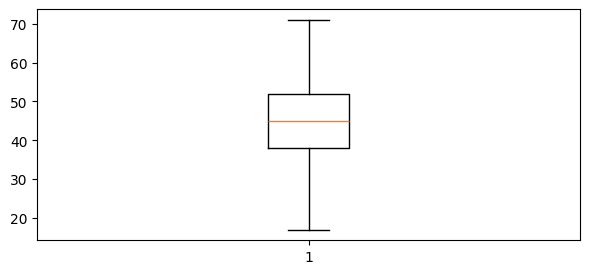

In [29]:
plt.figure(figsize=(7,3))
plt.boxplot(data["TMIN"])
plt.show

### Data Encoding

In [42]:
# data = pd.get_dummies(data,columns = ["RAIN"],dtype = "int")

In [43]:
data

,0,1
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
...,...,...
25543,1,0
25544,1,0
25545,1,0
25546,1,0
